In [8]:
import os
import h5py
import numpy as np

import opinf

import config_fhnlifted as config
import utils
import step1_generate_data as step1
import step2_fitgps as step2
import step3_estimate as step3
import step4_plot as step4

import matplotlib.pyplot

In [9]:
training_span = (0, 2) # (0, 6)
num_samples= 500 # 400
noiselevel= .0 # 0
num_regression_points= 400 # 400
numPODmodes= 3 # 3
gp_regularizer= 1e-4 # 1e-4
ndraws=100 # 100
exportto=None
openonsave=False
ddtdata=False

config.time_domain = np.linspace(0, 8, 801)  # Temporal domain t.

In [10]:
if isinstance(numPODmodes, (list, tuple)) and len(numPODmodes) == 1:
    numPODmodes = numPODmodes[0]

# Report on experimental scenario.
utils.summarize_experiment(
    training_span=training_span,
    num_samples=num_samples,
    noiselevel=noiselevel,
    num_regression_points=num_regression_points,
    numPODmodes=numPODmodes,
    gp_regularizer=gp_regularizer,
    ndraws=ndraws,
)

# Step 1: Generate data ---------------------------------------------------
(
    model,
    time_domain,
    true_states,
    time_domain_sampled,
    snapshots_sampled,
) = step1.trajectory(training_span, num_samples, config, noiselevel)


EXPERIMENTAL SCENARIO
Data: 500 uniformly sampled snapshots over 0.00 ≤ t < 2.00 with 0.00% noise
Dimension: retaining 3 POD modes
Training: using 400 regression points
GP regularization: eta = 1.00e-04
Posterior: 100 draws

generating training data...done in 0.25 s.


In [11]:
# Step 2: Fit Gaussian processes to data ----------------------------------
# Dimensionality reduction (POD).
with opinf.utils.TimedBlock(
    f"reducing noisy training states to {numPODmodes} dimensions"
):
    basis = config.Basis(num_vectors=numPODmodes)
    print(basis)
    print(f"Snapshot sampled shape: {snapshots_sampled.shape}")
    basis.fit(snapshots_sampled)
    ax = basis.plot_svdval_decay()
    ax.set_xlim(right=20)
    ax.set_ylim(bottom=1e-4)
    utils.save_figure("svdvals.pdf", andopen=openonsave)
    # print(f"{}")
    snapshots_compressed = basis.compress(snapshots_sampled)
    if exportto is not None:
        os.makedirs(os.path.dirname(exportto), exist_ok=True)
        np.save(f"{exportto}-svdvals.npy", basis.svdvals)
    
# Fit Gaussian process kernels to the compressed training data.
time_domain_training = np.linspace(
    training_span[0],
    training_span[-1],
    num_regression_points,
)
gps = step2.fit_gaussian_processes(
    time_domain_training=time_domain_training,
    time_domain_sampled=time_domain_sampled,
    snapshots_sampled=snapshots_compressed,
    gp_regularizer=gp_regularizer,
)
q0 = snapshots_compressed[:, 0]

reducing noisy training states to 3 dimensions...Basis
  full_state_dimension:    None
  reduced_state_dimension: None
  SVD solver: scipy.linalg.svd()
Snapshot sampled shape: (1024, 500)
(512, 500) (512, 500)
Saving /Users/anthonypoole/Repositories/GP-BayesOpInf/PDEs/figures/may01/09-45-04/svdvals.pdf...done in 0.30 s.
done in 0.44 s.

fitting GP model for state 'r_01'...


/Users/anthonypoole/miniconda3/envs/gpbayesopinf/lib/python3.12/site-packages/sklearn/gaussian_process/_gpr.py:659: ConvergenceWarning: lbfgs failed to converge (status=2):
ABNORMAL: .

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  _check_optimize_result("lbfgs", opt_res)


Gaussian radial basis function kernel
	k(t, t') = \sigma^2 exp(-(t - t')^2 / (2 \ell^2)) + \chi I
	\sigma^2 = 8.2094e+01
	\ell = 3.0341e-02
	\chi = 1.5962e-07
done in 45.11 s.
computing weight matrix...done in 0.04 s.

fitting GP model for state 'r_02'...


/Users/anthonypoole/miniconda3/envs/gpbayesopinf/lib/python3.12/site-packages/sklearn/gaussian_process/_gpr.py:659: ConvergenceWarning: lbfgs failed to converge (status=2):
ABNORMAL: .

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  _check_optimize_result("lbfgs", opt_res)


Gaussian radial basis function kernel
	k(t, t') = \sigma^2 exp(-(t - t')^2 / (2 \ell^2)) + \chi I
	\sigma^2 = 1.2968e+00
	\ell = 2.7307e-02
	\chi = 1.1864e-08
done in 38.63 s.
computing weight matrix...done in 0.04 s.

fitting GP model for state 'r_03'...


/Users/anthonypoole/miniconda3/envs/gpbayesopinf/lib/python3.12/site-packages/sklearn/gaussian_process/_gpr.py:659: ConvergenceWarning: lbfgs failed to converge (status=2):
ABNORMAL: .

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  _check_optimize_result("lbfgs", opt_res)


Gaussian radial basis function kernel
	k(t, t') = \sigma^2 exp(-(t - t')^2 / (2 \ell^2)) + \chi I
	\sigma^2 = 1.0807e+00
	\ell = 2.8422e-02
	\chi = 4.3999e-09
done in 38.73 s.
computing weight matrix...done in 0.06 s.


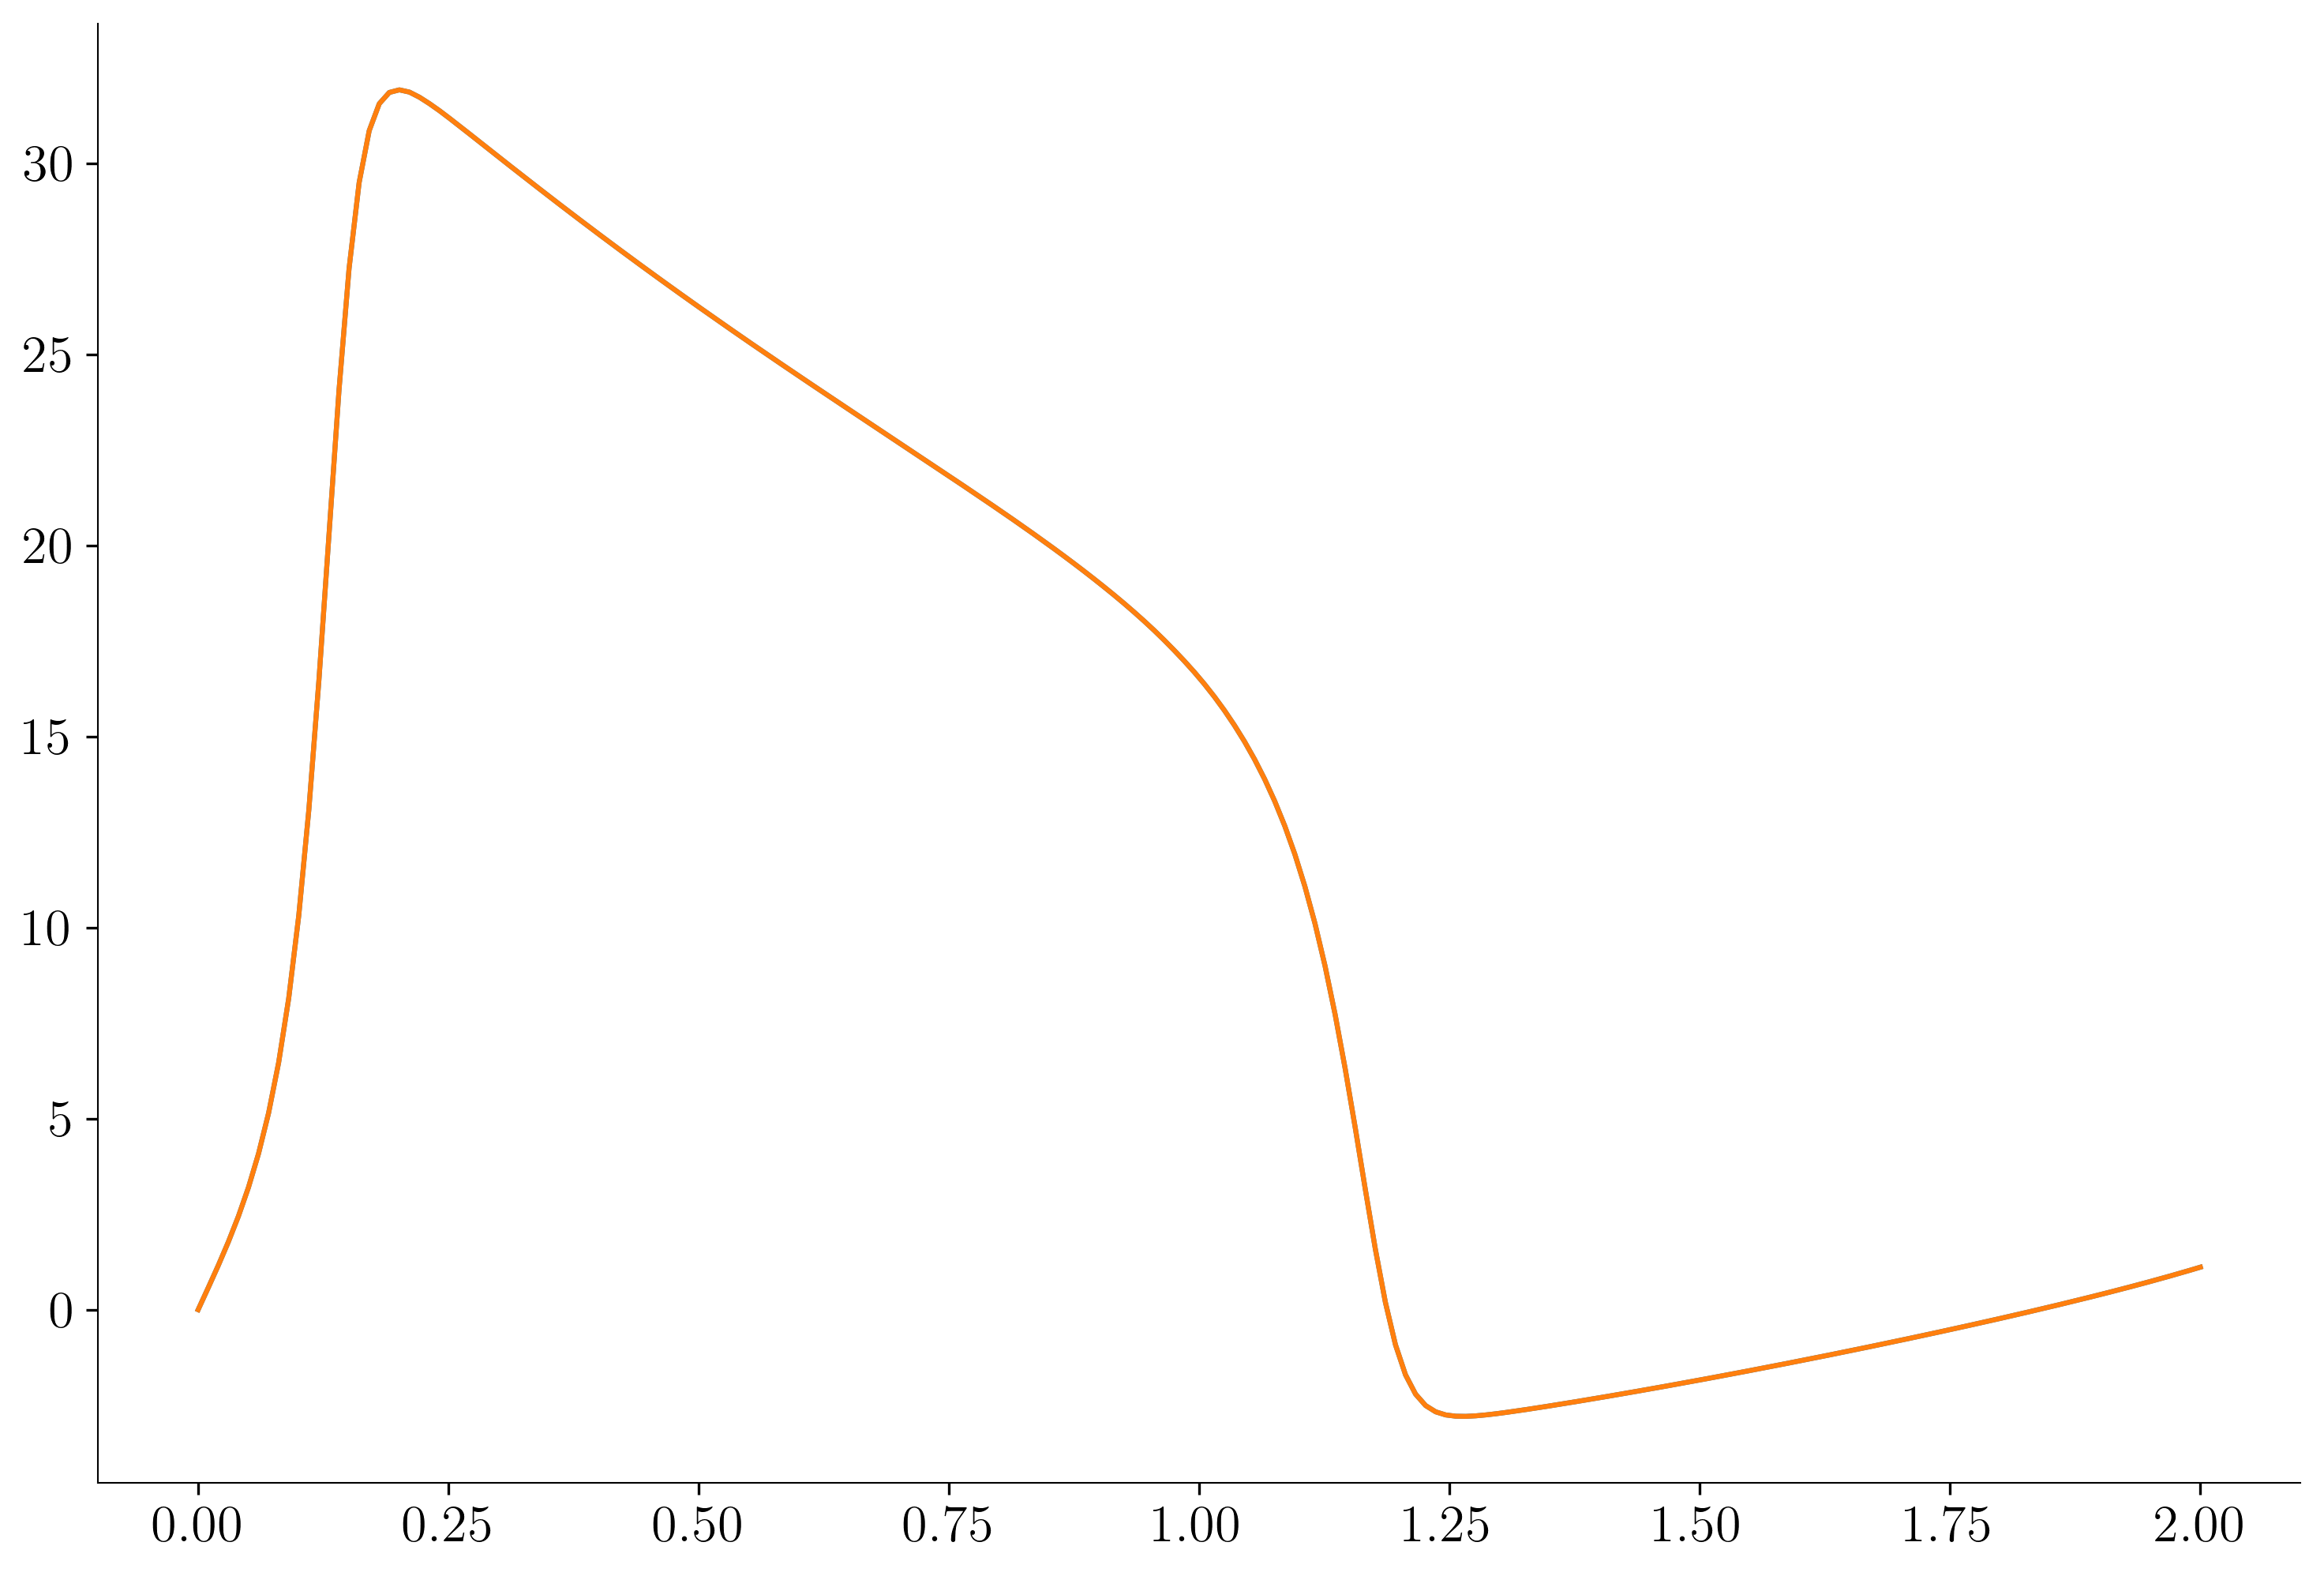

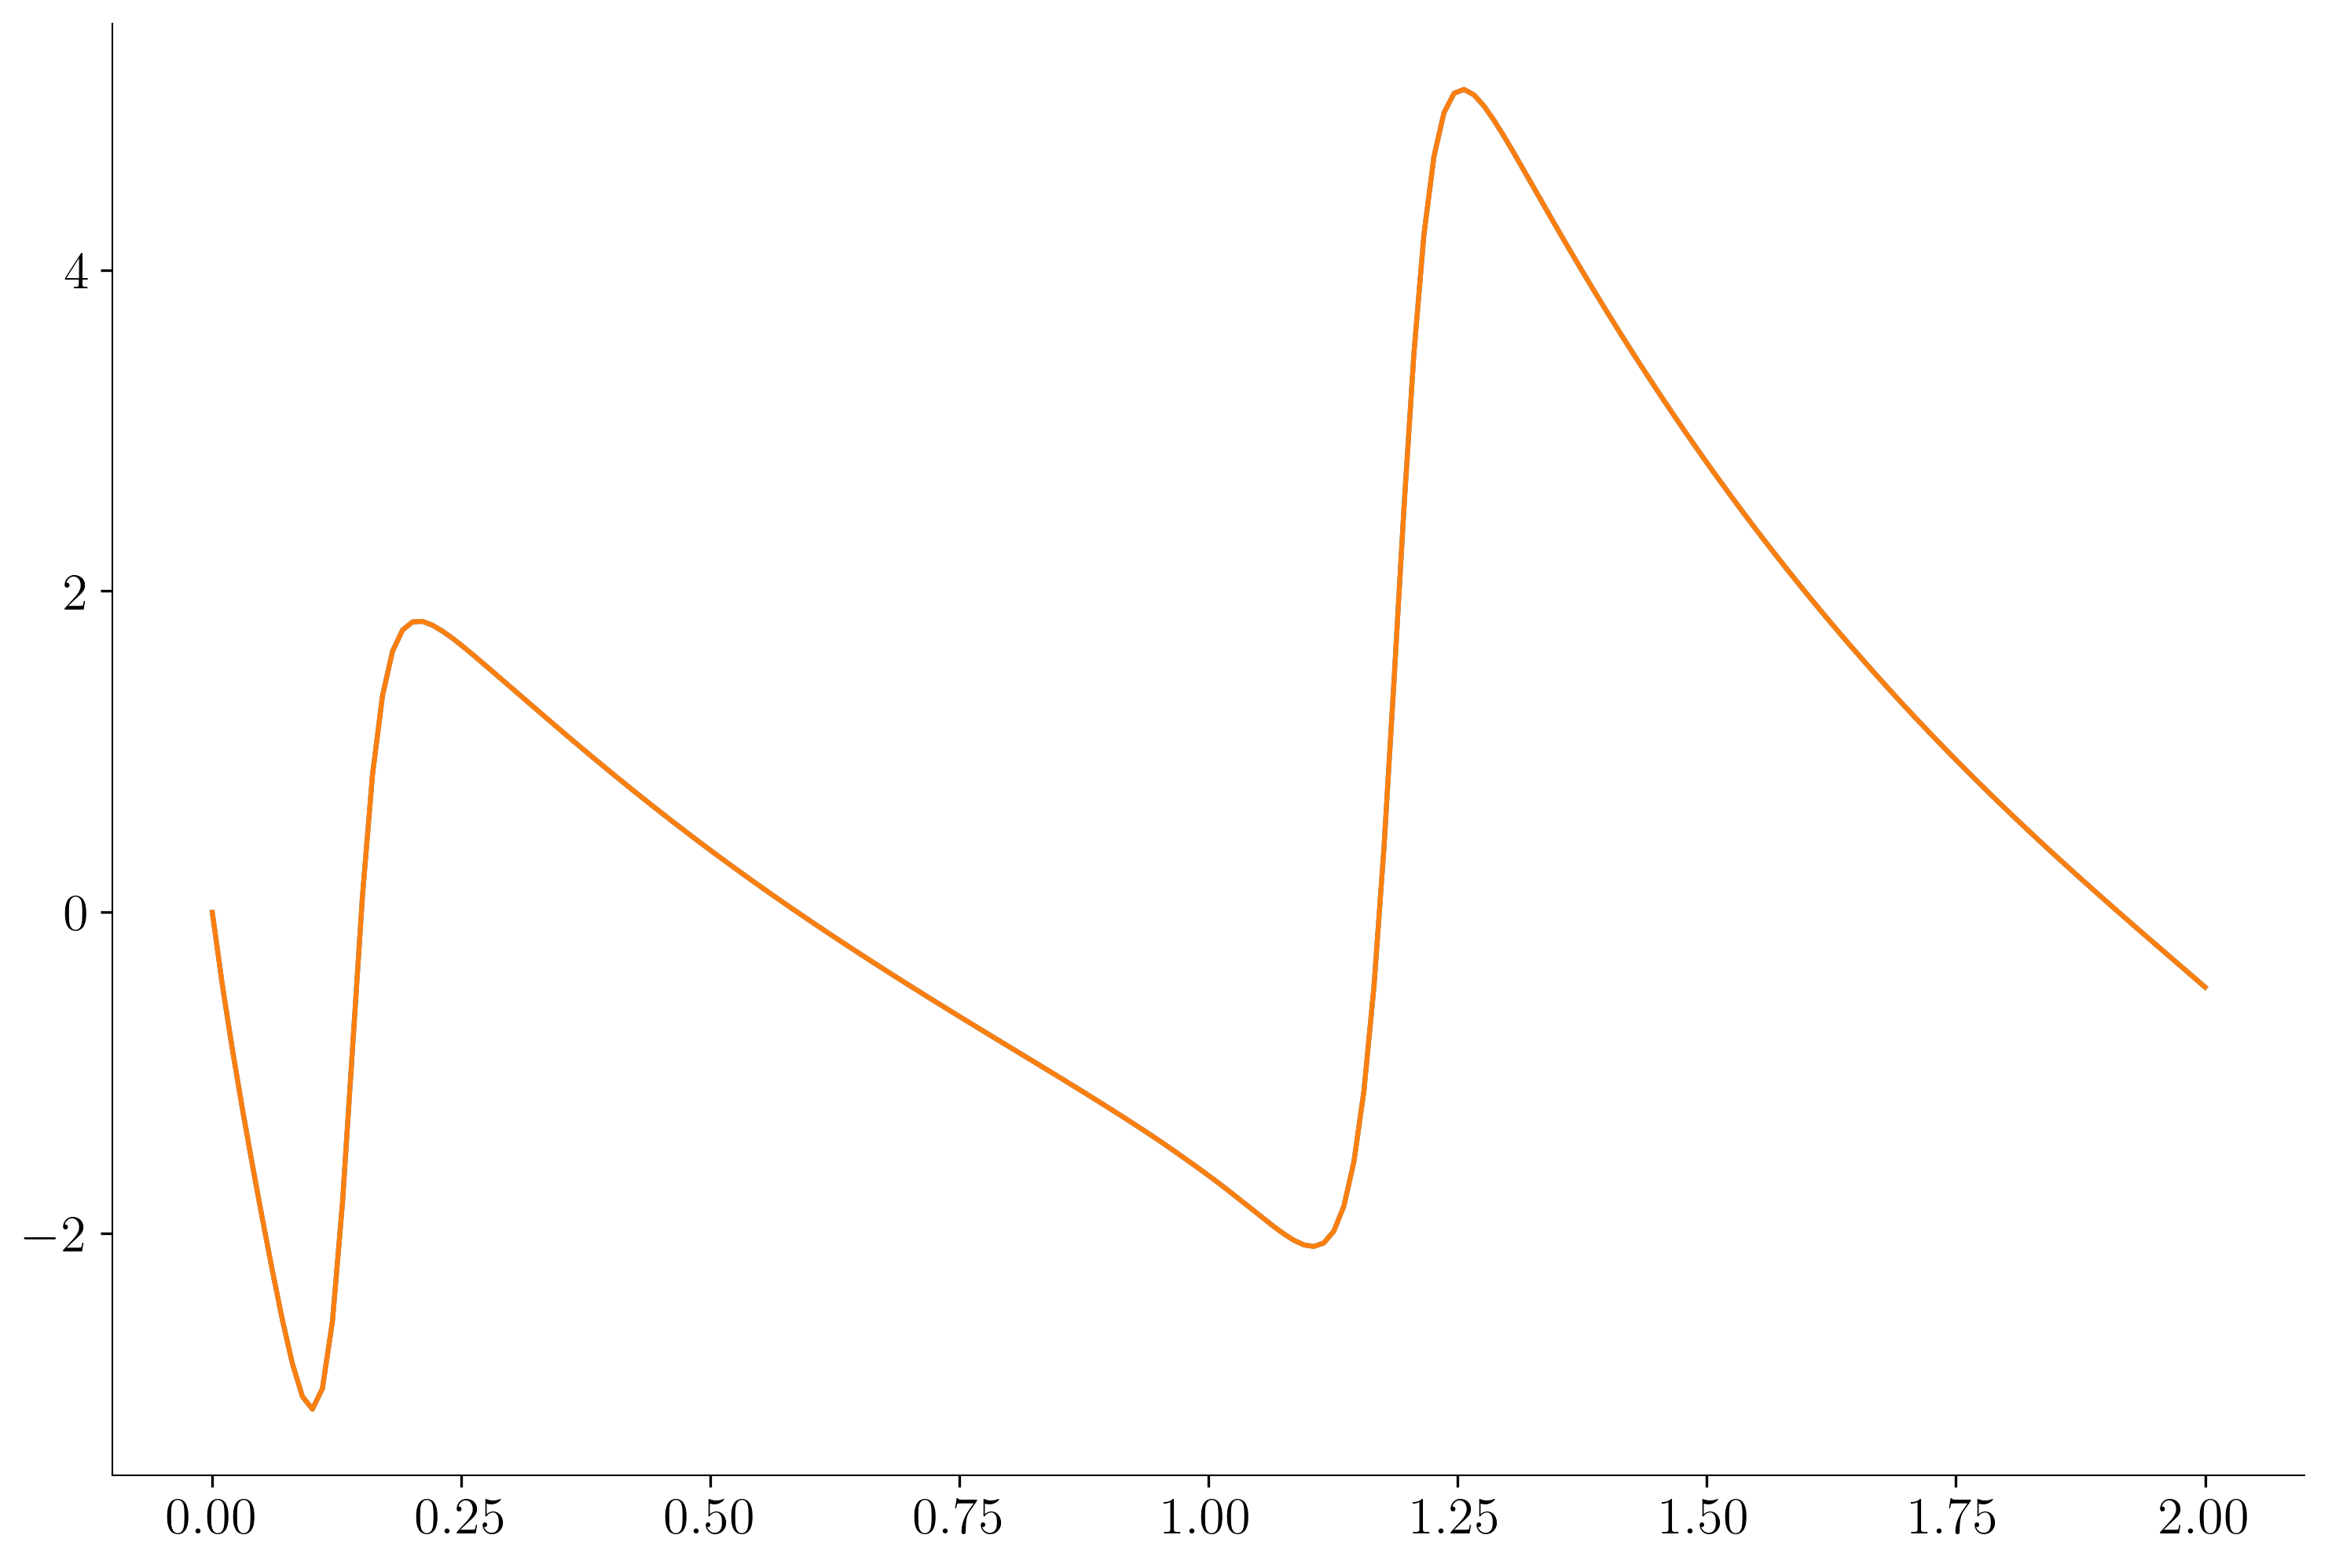

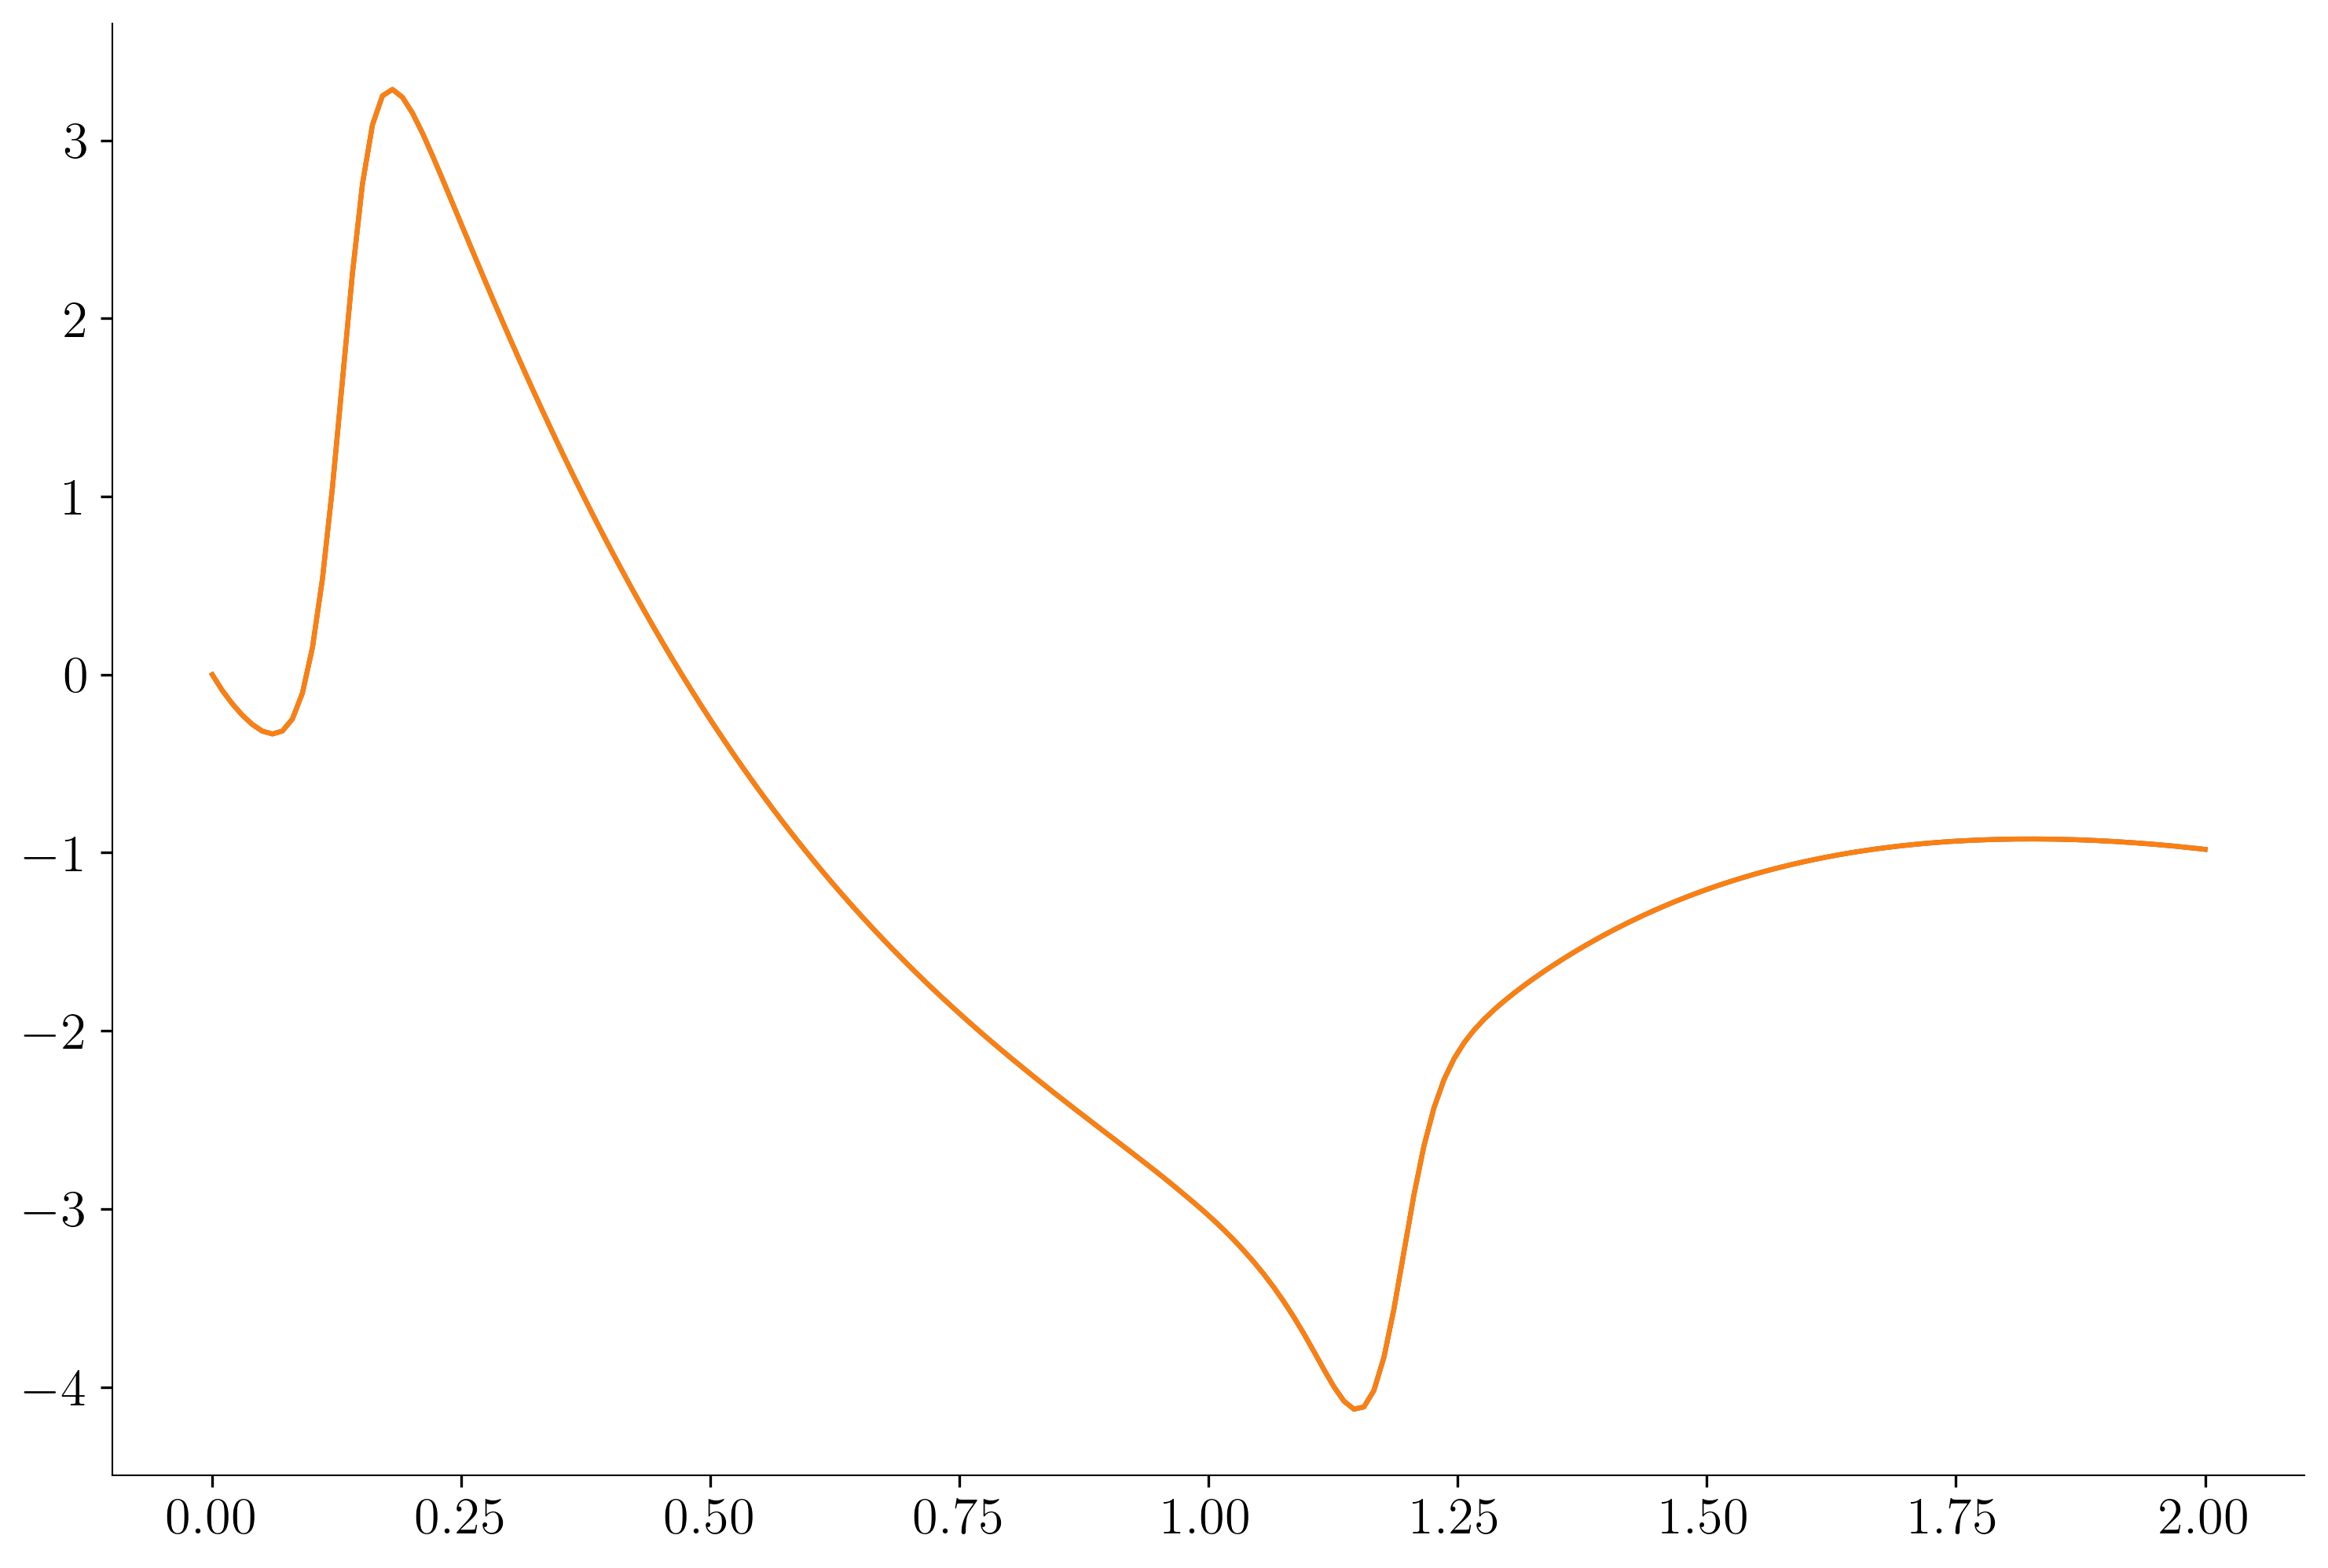

<Figure size 3600x2400 with 0 Axes>

In [12]:
import matplotlib.pyplot as plt
t = np.linspace(0,training_span[1],200)
for gp in gps:
    pred = gp.predict(t)
    for i in range(len(pred)):
        plt.plot(t, pred[0])
    plt.show()
    plt.clf()

In [13]:
input_func = config.ReducedOrderModel.input_func
print(input_func)
inputs = None if input_func is None else input_func(time_domain_training)
bayesian_model = step3.estimate_posterior(
    time_domain=time_domain,
    gps=gps,
    inputs=inputs,
    config=config
)

<function ReducedOrderModel.input_func at 0x14934cd60>
constructing posterior hyperparameters...

GRIDSEARCH
(1/81) Testing regularizer 1.0000e-16...2.72% error
(2/81) Testing regularizer 1.7783e-16...2.70% error
(3/81) Testing regularizer 3.1623e-16...2.69% error
(4/81) Testing regularizer 5.6234e-16...2.69% error
(5/81) Testing regularizer 1.0000e-15...2.71% error
(6/81) Testing regularizer 1.7783e-15...2.70% error
(7/81) Testing regularizer 3.1623e-15...2.69% error
(8/81) Testing regularizer 5.6234e-15...2.69% error
(9/81) Testing regularizer 1.0000e-14...2.71% error
(10/81) Testing regularizer 1.7783e-14...2.70% error
(11/81) Testing regularizer 3.1623e-14...2.72% error
(12/81) Testing regularizer 5.6234e-14...2.71% error
(13/81) Testing regularizer 1.0000e-13...2.70% error
(14/81) Testing regularizer 1.7783e-13...2.71% error
(15/81) Testing regularizer 3.1623e-13...2.69% error
(16/81) Testing regularizer 5.6234e-13...2.71% error
(17/81) Testing regularizer 1.0000e-12...2.72% error

In [14]:
# Draw samples from the posterior.
with opinf.utils.TimedBlock("sampling posterior distribution"):
    draws_compressed = []
    qbar = snapshots_compressed.mean(axis=1).reshape((-1, 1))
    bound = 5 * np.max(np.abs(snapshots_compressed - qbar), axis=1)
    num_unstables = 0
    for _ in range(ndraws):
        draw = bayesian_model.predict(
            initial_conditions=q0,
            timepoints=time_domain,
            input_func=input_func,
        )
        if draw.shape[1] != time_domain.size:
            num_unstables += 1
            continue
        if np.any(np.abs(draw - qbar).max(axis=1) > bound):
            num_unstables += 1
            continue
        draws_compressed.append(draw)
    if num_unstables:
        print(f"\n{num_unstables}/{ndraws} draws unstable")

    # Translate results back to original state space.
    draws = [basis.decompress(draw) for draw in draws_compressed]

# Step 4: plot results ----------------------------------------------------
gp_predictions = [gp.predict(time_domain_training) for gp in gps]
true_states_compressed = basis.compress(true_states)
true_states_projected = basis.decompress(true_states_compressed)

romplotter = step4.ReducedPlotter(
    sampling_time_domain=time_domain_sampled,
    training_time_domain=time_domain_training,
    prediction_time_domain=time_domain,
    snapshots_compressed=snapshots_compressed,
    true_states_compressed=true_states_compressed,
    gp_means=np.array([ms[0] for ms in gp_predictions]),
    gp_stds=np.array([ms[1] for ms in gp_predictions]),
    draws_compressed=draws_compressed,
)

stateplotter = step4.StatePlotter(
    sampling_time_domain=time_domain_sampled,
    training_time_domain=time_domain_training,
    prediction_time_domain=time_domain,
    spatial_domain=config.spatial_domain,
    num_variables=config.FullOrderModel.num_variables,
    snapshots=snapshots_sampled,
    true_states=true_states,
    true_states_projected=true_states_projected,
    draws=draws,
    numspatialpoints=-1,
)

# If desired, export experimental data to HDF5 files for later.
if exportto is not None:
    reduced_dfile = f"{exportto}_data-reduced.h5"
    with opinf.utils.TimedBlock(
        f"exporting reduced data to {reduced_dfile}"
    ):
        romplotter.save(reduced_dfile, overwrite=True)
    full_dfile = f"{exportto}_data-full.h5"
    with opinf.utils.TimedBlock(f"exporting full data to {full_dfile}"):
        stateplotter.save(full_dfile, overwrite=True)

# Plot and save results.
with opinf.utils.TimedBlock("plotting model performance\n"):
    # Gaussian process fit in the reduced state space.
    romplotter.plot_gp_training_fit(width=3)
    utils.save_figure("train.pdf", andopen=openonsave)

    for k, flag in enumerate((True, False)):
        # Bayesian ROM performance in the reduced state space.
        romplotter.plot_posterior(individual=flag)
        utils.save_figure(f"predict{k:d}.pdf", andopen=openonsave)

        # Bayesian ROM performance in the original state space.
        figures = stateplotter.plot_posterior(individual=flag)
        for d, fig in enumerate(figures):
            utils.save_figure(
                f"predict{k+1:d}-{d+1}.pdf",
                fig=fig,
                andopen=openonsave,
            )

# Save Gaussian process derivative data (for visualization only).
if ddtdata:
    if exportto is None:
        raise ValueError("argument 'exportto' required when ddtdata given")
    # Get moments of the derivative of each Gaussian process.
    dqdtmeans = np.array([gp.ddt_estimate for gp in gps])
    dqdtstds = np.array(
        [
            np.std(
                np.random.multivariate_normal(
                    gp.ddt_estimate,
                    gp.ddt_covariance,
                    size=ndraws,
                ),
                axis=0,
            )
            for gp in gps
        ]
    )
    # Estimate time derivatives with finite differences of the snapshots.
    dqdtFD = np.gradient(
        snapshots_compressed,
        time_domain_sampled,
        edge_order=2,
        axis=1,
    )

    # Get true derivatives from intrusive model information.
    t_fine = np.linspace(
        time_domain_training[0],
        time_domain_training[-1],
        1000,
    )
    truth_fine = model.solve(config.initial_conditions, t_fine)
    truth_fine_nonlifted = model.unlift(truth_fine)
    dQdt_nonlifted = model.derivative(t_fine, truth_fine_nonlifted)
    dQdt_fine = model.lift_ddts(truth_fine_nonlifted, dQdt_nonlifted)
    dQdt_compressed = basis.entries.T @ basis.nondimensionalize(dQdt_fine)

sampling posterior distribution...done in 2.87 s.
plotting model performance...
Saving /Users/anthonypoole/Repositories/GP-BayesOpInf/PDEs/figures/may01/09-45-04/train.pdf...done in 0.21 s.
Saving /Users/anthonypoole/Repositories/GP-BayesOpInf/PDEs/figures/may01/09-45-04/predict0.pdf...done in 0.18 s.
Saving /Users/anthonypoole/Repositories/GP-BayesOpInf/PDEs/figures/may01/09-45-04/predict1-1.pdf...done in 0.21 s.
Saving /Users/anthonypoole/Repositories/GP-BayesOpInf/PDEs/figures/may01/09-45-04/predict1-2.pdf...done in 0.22 s.
Saving /Users/anthonypoole/Repositories/GP-BayesOpInf/PDEs/figures/may01/09-45-04/predict1.pdf...done in 0.14 s.
Saving /Users/anthonypoole/Repositories/GP-BayesOpInf/PDEs/figures/may01/09-45-04/predict2-1.pdf...done in 0.16 s.
Saving /Users/anthonypoole/Repositories/GP-BayesOpInf/PDEs/figures/may01/09-45-04/predict2-2.pdf...done in 0.17 s.
done in 2.06 s.
